# Model Specification

When working with **MCSimMod**, one must define an ordinary differential equation (ODE) model using "model specification" text. Such text can be provided as a text (character) string or as a text file. In either case, the text should be formatted according to the rules of the [GNU MCSim](https://www.gnu.org/software/mcsim/) model specification language. To demonstrate this, we will consider a simple ODE model for exponential growth or decay.

## A Mathematical Model for Exponential Growth or Decay

A quantity undergoes exponential growth or decay when the rate of change of the quantity is proportional to the amount currently present. So, if $A(t)$ is the amount at time $t$ and $r$ is the exponential rate of change (with units of one over time), then
\begin{equation}
  \frac{\textrm{d}}{\textrm{d}t}A(t) = r \cdot A(t).
\end{equation}
When $r$ is positive, the process is known as exponential growth, and when $r$ is negative, the process is known as exponential decay.

In order to solve an initial value problem involving an exponential growth or decay differential equation, one needs to specify the exponential rate $r$ and an initial amount $A_0$ such that $A(0) = A_0$.

## MCSim Model Specification

We will use the [GNU MCSim](https://www.gnu.org/software/mcsim/) model specification language to implement the exponential model. Recall that this model has a single state variable, $A$, and two parameters, $r$ and $A_0$, the latter of which is an initial condition for the state variable. All of these components of the exponential model can be included in a text file that we refer to as an "MCSim model specification file." The model specification text should be written using standard C statements, which may include the assignment operator (`=`), arithmetic operators (`+`, `-`, `*`, `/`, and `%`), and various mathematical functions (e.g., `pow`, `exp`, `log`, `sin`, and `cos`). A full description of rules and syntax for MCSim model specification files can be found in Section 5 of the [GNU MCSim User's Manual](https://www.gnu.org/software/mcsim/mcsim.html).

The complete MCSim model specification file for the exponential model, `exponential.model`, can be found in the `extdata` subdirectory of the **MCSimMod** package installation directory. Here, we describe the seven essential elements of that file.

### Element 1: States

The first element of the MCSim model specification file is a listing of the state variables in the ordinary differential equation (ODE) model. We use the text symbol `A` to represent the state variable $A$ in the exponential model.
```{verbatim}
# STATE VARIABLES for the model (for which ODEs are provided).
States = {
    A,        # Amount of substance.
};
```
Note that the `#` character indicates the start of a comment. That is, any text following the `#` character on any line will be ignored when translating the model specification file into machine language. Note also that the state variables should be provided in a comma-delimited list that begins with `{` and ends with `};` (with a semicolon).

### Element 2: Outputs

The model specification file can also include a listing of the "output variables" for the model. These are variables for which values can be calculated as analytic functions of state variables, "input variables" (which will be described next), and/or parameters. For the exponential model, we will not include any output variables, so we will provide a blank list in this case. (This element of the model specification file is optional -- it could be omitted.)
```{verbatim}
# OUTPUT VARIABLES for the model (which can be obtained at any point in time
# as analytic functions of state variables, input variables, and parameters).
Outputs = {};
```

### Element 3: Inputs

Another optional element of the model specification file is a listing of the "input variables" for the model. These variables are independent of other variables and can vary in time. For the exponential model, we will not include any input variables. (This element of the model specification file is optional -- it could be omitted.)
```{verbatim}
# INPUT VARIABLES for the model (which are independent of other variables, and
# which may vary in time).
Inputs = {};
```

### Element 4: Parameters

The next element of the model specification file allows one to name the parameters and to provide default values for those parameters. (Note that the parameter values to be used for specific model simulations can be changed without editing the model specification file.) Recall that the parameters for the exponential model are $A_0$ and $r$, for which we use the text symbols `A0` and `r`, respectively.
```{verbatim}
# PARAMETERS for the model (which are independent of time).
A0 = 0;          # Initial amount.
r = 0;           # Exponential rate of change (time^-1).
```

### Element 5: Initialize Section

The "Initialize" section is the next element of the model specification file. In this section, the values of any static parameters that need to be calculated (e.g., based on the values of other parameters) can be determined and initial values of the state variables can be provided. Note that this section begins with `Initialize {` and ends with `}` (with no semicolon).
```{verbatim}
# MODEL INITIALIZATION section.
Initialize {
    # Assign an initial value for each state variable.
    A = A0;
}
```

### Element 6: Dynamics Section

Next, we have the "Dynamics" section. In this section of the model specification file, the state equations (ODEs) for all state variables should be provided. This section begins with `Dynamics {` and ends with `}` (with no semicolon). For each state variable in the model, the state equation should be provided using `dt` followed by the text symbol for the state variable in parentheses, the `=` symbol, and then a mathematical expression that represents the time rate of change of the state variable.
```{verbatim}
# DYNAMICS section.
Dynamics {
    # Time rate of change (ODE) for each state variable.
    dt(A) = r * A;
}
```

### Element 7: End Keyword
The final element of the model specification file is the "End" keyword (which is followed by a period).
```{verbatim}
End.
```

## Building the Model

Next, we will use the **PyMCSimMod** package to define the exponential ODE model and solve an initial value problem. Solving an initial value problem is synonymous with "performing a simulation" with the model.

First, we load the **PyMCSimMod** package as follows.

In [1]:
%load_ext autoreload
%autoreload 2

from pymcsimmod import create_model

Using the following commands, we create an exponential model object (i.e., an instance of the `ScipyModel` class) using the model specification file `exponential.model` that is included in the **PyMCSimMod** package.

In [2]:
import importlib.resources
with importlib.resources.path('pymcsimmod.data', 'exponential.model') as filename:
    exp_mod = create_model(filename, backend="scipy")

## Solving an Initial Value Problem (i.e., Performing a Model Simulation)

Next, we can change the parameter values from their default values (which are given in the model specification file) to the values we wish to use for our simulation (i.e., $A_0 = 100$ and $r = -0.5$). 

In [3]:
# Change the values of the model parameters from their default values: set the
# initial amount (A0) to 100 and the exponential rate (r) to -0.5.
exp_mod.update_constants(A0 = 100, r = -0.5)

print(exp_mod.parameters)

# When updating A0, the initial condition is automatically updated.
print(exp_mod.Y0)

{'A0': 100, 'r': -0.5}
{'A': 100}


Note that executing the command `exp_model.update_constants(A0=100, r=-0.5)` updates the parameter values (replacing the default values that were provided in the model specification file) and also updates the initial value of the state variable `A` using the updated value of the parameter `A0`. (The class methods `update_constants()` and `update_Y0()` implement any logic provided in the "Initialize" section of the model specification file.)

Finally, we can perform a simulation that provides results for the desired output times (i.e., $t = 0, 0.1, 0.2, \ldots, 20.0$) using the following commands.

In [4]:
import numpy as np
# Define output times for simulation.
times = np.arange(start = 0, stop = 20, step = 0.1)

# Run simulation.
results = exp_mod.run_model(times)

## Examining the Results

The `results` object returned by the `run_model()` method is a `ComputedModel` object containing the simulation results, which can be accessed and analyzed as needed. The `dataframe` attribute of the `ComputedModel` object contains a pandas DataFrame with the simulation results, where each row corresponds to a time point and the columns corresponds are the simulated times, state variables or output variables.

In [5]:
out = results.dataframe
display(out.head())

,time,A
0,0.0,100.000000
1,0.1,95.154538
2,0.2,90.525414
3,0.3,86.113408
4,0.4,81.909765


We can examine the parameter values and initial conditions that were used for this simulation with the following commands.

In [6]:
print(exp_mod.parameters)
print(exp_mod.Y0)

{'A0': 100, 'r': -0.5}
{'A': 100}


Finally, we can create a visual representation of the simulation results using the `ComputedModel` object that has built-in plotting capabilities. For example, we can plot the amount vs. time using `plot_results` which returns an `axes` object from `matplotlib`.

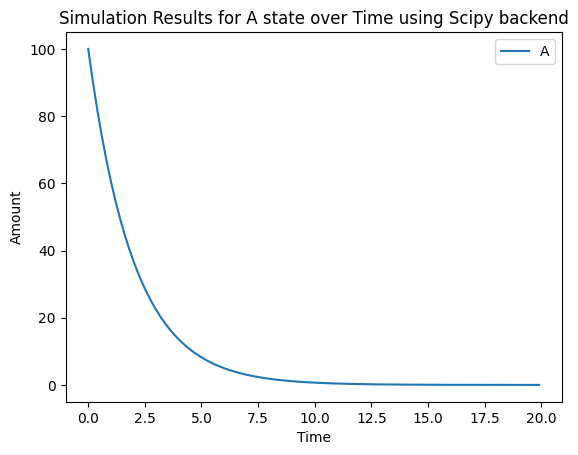

In [7]:
ax = results.plot_results(variables=['A'], xlabel='Time', ylabel='Amount')
_ = ax.set_title('Simulation Results for A state over Time using Scipy backend')